Cell 1 — Imports and Paths

In [20]:
import os, pickle, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from collections import Counter
import matplotlib.pyplot as plt
import psutil

DATA_PATH       = r"D:\CSE-CICIDS2018"
ARTIFACT_PATH   = r"..\artifacts"
CHECKPOINT_PATH = r"..\checkpoints"

os.makedirs(ARTIFACT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

FILES = [
    "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
]

FEATURES = [
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
    'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
    'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd PSH Flags',
    'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio',
    'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
]

# Attack type grouping — raw CSV label → grouped class string
LABEL_GROUPING = {
    'Benign':                    'BENIGN',
    'FTP-BruteForce':            'BruteForce',
    'SSH-Bruteforce':            'BruteForce',
    'Brute Force -Web':          'BruteForce',
    'Brute Force -XSS':          'BruteForce',
    'DoS attacks-Hulk':          'DoS',
    'DoS attacks-GoldenEye':     'DoS',
    'DoS attacks-Slowloris':     'DoS',
    'DoS attacks-SlowHTTPTest':  'DoS',
    'DDoS attacks-LOIC-HTTP':    'DDoS',
    'DDOS attack-HOIC':          'DDoS',
    'DDOS attack-LOIC-UDP':      'DDoS',
    'SQL Injection':             'WebAttack',
    'Infilteration':             'Infiltration',
    'Bot':                       'Botnet',
}

# Integer encoding — BENIGN must be 0
CLASS_ORDER = ['BENIGN', 'DoS', 'DDoS', 'BruteForce', 'WebAttack', 'Infiltration', 'Botnet']
LABEL_MAP = {i: name for i, name in enumerate(CLASS_ORDER)}   # {0: 'BENIGN', ...}
STR_TO_INT = {name: i for i, name in LABEL_MAP.items()}       # {'BENIGN': 0, ...}

print(f"Files: {len(FILES)}")
print(f"Classes: {CLASS_ORDER}")
print(f"Label map: {LABEL_MAP}")
print("Imports OK")

Files: 10
Classes: ['BENIGN', 'DoS', 'DDoS', 'BruteForce', 'WebAttack', 'Infiltration', 'Botnet']
Label map: {0: 'BENIGN', 1: 'DoS', 2: 'DDoS', 3: 'BruteForce', 4: 'WebAttack', 5: 'Infiltration', 6: 'Botnet'}
Imports OK


Cell 2 — Load and Clean (with checkpoint)

In [21]:
CHECKPOINT_FILE = os.path.join(CHECKPOINT_PATH, 'df_multiclass.pkl')
TUESDAY_FILE    = "Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv"

if os.path.exists(CHECKPOINT_FILE):
    print("Checkpoint found — loading df_multiclass")
    df = pd.read_pickle(CHECKPOINT_FILE)
    print(f"Loaded shape: {df.shape}")
else:
    frames = []

    for fname in FILES:
        fpath = os.path.join(DATA_PATH, fname)
        print(f"\nLoading {fname}...")

        if fname == TUESDAY_FILE:
            print("  Large file — chunked loading...")
            chunks = []
            for chunk in pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False,
                chunksize=500_000
            ):
                chunk.columns = chunk.columns.str.strip()
                chunk = chunk[chunk['Label'] != 'Label']
                for col in chunk.select_dtypes(include='float64').columns:
                    chunk[col] = chunk[col].astype('float32')
                chunks.append(chunk)
            file_df = pd.concat(chunks, ignore_index=True)
            del chunks; gc.collect()
        else:
            file_df = pd.read_csv(
                fpath,
                usecols=lambda c: c.strip() in FEATURES + ['Label'],
                low_memory=False
            )
            file_df.columns = file_df.columns.str.strip()
            file_df = file_df[file_df['Label'] != 'Label']
            for col in file_df.select_dtypes(include='float64').columns:
                file_df[col] = file_df[col].astype('float32')

        print(f"  Shape: {file_df.shape} | Labels: {file_df['Label'].unique()}")
        frames.append(file_df)
        del file_df; gc.collect()

    print("\nConcatenating...")
    df = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    print(f"Raw combined shape: {df.shape}")

    # Apply grouping
    df['Label'] = df['Label'].map(LABEL_GROUPING)
    before = len(df)
    df.dropna(subset=['Label'], inplace=True)  # rows not in mapping
    print(f"Rows dropped (unknown labels): {before - len(df)}")

    # Clean
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    before = len(df)
    df.dropna(inplace=True)
    print(f"NaN rows dropped: {before - len(df)}")

    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows dropped: {before - len(df)}")

    df.to_pickle(CHECKPOINT_FILE)
    print(f"\nCheckpoint saved. Final shape: {df.shape}")

Checkpoint found — loading df_multiclass
Loaded shape: (9776643, 26)


Cell 3 — Label Distribution

In [22]:
print("=== GROUPED LABEL DISTRIBUTION ===\n")
counts = df['Label'].value_counts()
print(counts)
print(f"\nTotal rows: {len(df):,}")

=== GROUPED LABEL DISTRIBUTION ===

Label
BENIGN          8487399
DDoS             775198
DoS              172944
Botnet           143395
Infiltration     102858
BruteForce        94769
WebAttack            80
Name: count, dtype: int64

Total rows: 9,776,643


Cell 4 — Encode, Split, Scale, SMOTE (with checkpoint)

In [23]:
CHECKPOINT_SPLIT = os.path.join(CHECKPOINT_PATH, 'split_multiclass.pkl')

if os.path.exists(CHECKPOINT_SPLIT):
    print("Checkpoint found — loading split_multiclass")
    with open(CHECKPOINT_SPLIT, 'rb') as f:
        X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)
    print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")
    print(f"Class distribution in train:\n{Counter(y_train)}")

else:
    # Encode labels to integers
    df['y'] = df['Label'].map(STR_TO_INT)
    X = df[FEATURES].values.astype('float32')
    y = df['y'].values
    del df; gc.collect()

    # Fix any remaining inf
    print(f"Inf before clean: {np.isinf(X).sum()}")
    X = np.where(np.isinf(X), np.nan, X)
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])
    print(f"Inf after clean: {np.isinf(X).sum()}")

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    del X; gc.collect()
    print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

    # NEW separate scaler — never touch binary scaler.pkl
    scaler_mc = RobustScaler()
    X_train_scaled = scaler_mc.fit_transform(X_train)
    X_test_scaled  = scaler_mc.transform(X_test)
    del X_train; gc.collect()

    with open(os.path.join(ARTIFACT_PATH, 'scaler_multiclass.pkl'), 'wb') as f:
        pickle.dump(scaler_mc, f)
    print("scaler_multiclass.pkl saved")

    # SMOTE — two-tier, same strategy as binary training
    before = Counter(y_train)
    print(f"\nBefore SMOTE:")
    for k, v in sorted(before.items(), key=lambda x: x[1]):
        print(f"  {LABEL_MAP[k]}: {v:,}")

    print(f"\nRAM before SMOTE: {psutil.virtual_memory().percent:.1f}%")

    tier1 = {k: 2000 for k, v in before.items() if v < 500 and k != STR_TO_INT['BENIGN']}
    print(f"\nTier 1 (k=3, < 500 → 2000): {[LABEL_MAP[k] for k in tier1]}")
    if tier1:
        sm1 = SMOTE(sampling_strategy=tier1, random_state=42, k_neighbors=3)
        X_train_scaled, y_train = sm1.fit_resample(X_train_scaled, y_train)
        del sm1; gc.collect()

    tier2 = {k: 5000 for k, v in before.items() if 500 <= v < 5000 and k != STR_TO_INT['BENIGN']}
    print(f"Tier 2 (k=5, 500-5000 → 5000): {[LABEL_MAP[k] for k in tier2]}")
    if tier2:
        sm2 = SMOTE(sampling_strategy=tier2, random_state=42, k_neighbors=5)
        X_train_scaled, y_train = sm2.fit_resample(X_train_scaled, y_train)
        del sm2; gc.collect()

    print(f"\nRAM after SMOTE: {psutil.virtual_memory().percent:.1f}%")
    print(f"\nAfter SMOTE:")
    for k, v in sorted(Counter(y_train).items(), key=lambda x: x[1]):
        print(f"  {LABEL_MAP[k]}: {v:,}")

    with open(CHECKPOINT_SPLIT, 'wb') as f:
        pickle.dump((X_train_scaled, X_test_scaled, y_train, y_test), f)
    print("\nSplit checkpoint saved")

Checkpoint found — loading split_multiclass
X_train: (7823250, 25) | X_test: (1955329, 25)
Class distribution in train:
Counter({np.int64(0): 6789919, np.int64(2): 620158, np.int64(1): 138355, np.int64(6): 114716, np.int64(5): 82287, np.int64(3): 75815, np.int64(4): 2000})


Cell 5 — Train XGBoost Multiclass

In [24]:
import time

CHECKPOINT_MODEL_MC = os.path.join(ARTIFACT_PATH, 'model_multiclass.pkl')

if os.path.exists(CHECKPOINT_MODEL_MC):
    print("model_multiclass.pkl found — loading")
    with open(CHECKPOINT_MODEL_MC, 'rb') as f:
        model_mc = pickle.load(f)
    print(f"Loaded: {type(model_mc).__name__}")

else:
    n_classes = len(CLASS_ORDER)
    print(f"Training multiclass XGBoost ({n_classes} classes)...")

    model_mc = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        objective='multi:softprob',
        num_class=n_classes,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        verbosity=0,
    )

    # 3-fold CV (faster than 5-fold on multiclass at this scale)
    print("Running 3-fold CV...")
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        model_mc, X_train_scaled, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=1
    )
    print(f"CV F1-weighted: {cv_scores.round(4)} | mean={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    print("\nTraining final model...")
    t0 = time.time()
    model_mc.fit(X_train_scaled, y_train)
    print(f"Done in {time.time()-t0:.1f}s")

    with open(CHECKPOINT_MODEL_MC, 'wb') as f:
        pickle.dump(model_mc, f)
    print("model_multiclass.pkl saved")

model_multiclass.pkl found — loading
Loaded: XGBClassifier


Cell 6 — Evaluate

=== MULTICLASS CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99   1697480
         DoS       0.83      0.84      0.83     34589
        DDoS       0.95      0.95      0.95    155040
  BruteForce       1.00      0.99      1.00     18954
   WebAttack       0.09      0.75      0.16        16
Infiltration       0.55      0.03      0.06     20571
      Botnet       1.00      0.99      1.00     28679

    accuracy                           0.98   1955329
   macro avg       0.77      0.79      0.71   1955329
weighted avg       0.98      0.98      0.98   1955329



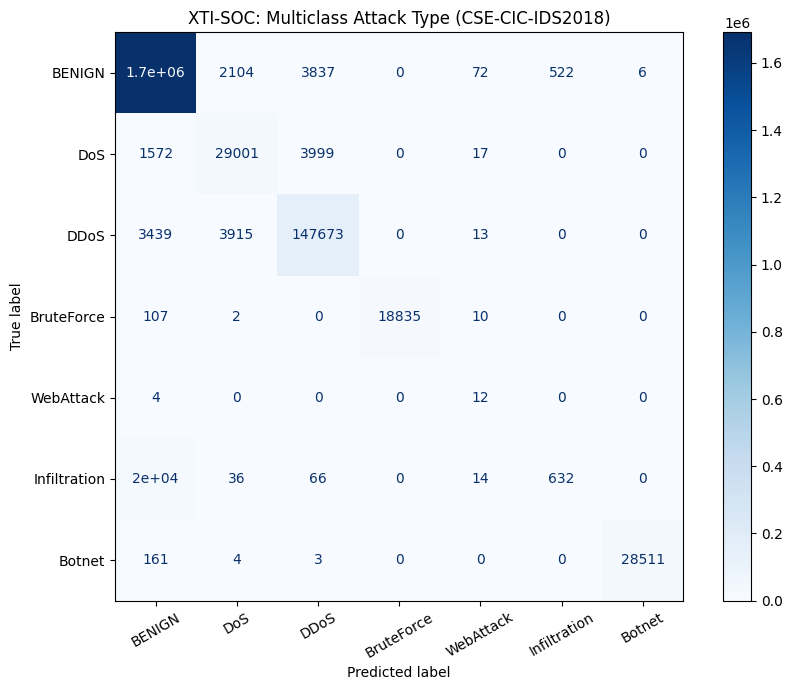

confusion_matrix_multiclass.png saved


In [25]:
y_pred_mc = model_mc.predict(X_test_scaled)

target_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP.keys())]

print("=== MULTICLASS CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_mc, target_names=target_names))

cm = confusion_matrix(y_test, y_pred_mc)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=30)
plt.title('XTI-SOC: Multiclass Attack Type (CSE-CIC-IDS2018)')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_PATH, 'confusion_matrix_multiclass.png'), dpi=150)
plt.show()
print("confusion_matrix_multiclass.png saved")

Cell 7 — Save label_map and Verify All Artifacts

In [26]:
# Save label map
with open(os.path.join(ARTIFACT_PATH, 'label_map.pkl'), 'wb') as f:
    pickle.dump(LABEL_MAP, f)
print(f"label_map.pkl saved: {LABEL_MAP}")

# Verify
print("\n=== ARTIFACT VERIFICATION ===\n")
mc_artifacts = ['model_multiclass.pkl', 'scaler_multiclass.pkl', 'label_map.pkl']
for a in mc_artifacts:
    path = os.path.join(ARTIFACT_PATH, a)
    size = os.path.getsize(path) / 1024**2
    print(f"✓ {a:30s} {size:.1f} MB")

# Reload and smoke test
with open(os.path.join(ARTIFACT_PATH, 'model_multiclass.pkl'), 'rb') as f:
    m_mc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'scaler_multiclass.pkl'), 'rb') as f:
    sc_mc = pickle.load(f)
with open(os.path.join(ARTIFACT_PATH, 'label_map.pkl'), 'rb') as f:
    lm = pickle.load(f)

dummy = np.zeros((1, 25), dtype='float32')
dummy_scaled = sc_mc.transform(dummy)
pred_int = int(m_mc.predict(dummy_scaled)[0])
pred_label = lm[pred_int]

print(f"\nSmoke test: predict([[0]*25]) → class {pred_int} = '{pred_label}'")
assert lm[0] == 'BENIGN', f"BENIGN must be class 0! Got: {lm[0]}"
print("✅ label_map[0] == 'BENIGN' — confirmed")

# Confirm binary artifacts untouched
print("\n=== BINARY ARTIFACTS STILL INTACT ===")
for a in ['model.pkl', 'scaler.pkl', 'explainer.pkl', 'feature_list.pkl']:
    path = os.path.join(ARTIFACT_PATH, a)
    exists = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"{exists} {a}")

print("\n=== MULTICLASS TRAINING COMPLETE ===")
print("Ready to update ml_engine.py for two-model predict()")

label_map.pkl saved: {0: 'BENIGN', 1: 'DoS', 2: 'DDoS', 3: 'BruteForce', 4: 'WebAttack', 5: 'Infiltration', 6: 'Botnet'}

=== ARTIFACT VERIFICATION ===

✓ model_multiclass.pkl           11.5 MB
✓ scaler_multiclass.pkl          0.0 MB
✓ label_map.pkl                  0.0 MB

Smoke test: predict([[0]*25]) → class 0 = 'BENIGN'
✅ label_map[0] == 'BENIGN' — confirmed

=== BINARY ARTIFACTS STILL INTACT ===
✓ model.pkl
✓ scaler.pkl
✓ explainer.pkl
✓ feature_list.pkl

=== MULTICLASS TRAINING COMPLETE ===
Ready to update ml_engine.py for two-model predict()


=========SOMETESTS=========

In [27]:
print(model_mc)
print(model_mc.n_estimators)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_class=7, num_parallel_tree=None, ...)
300


In [28]:
from sklearn.metrics import classification_report

y_pred = model_mc.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99   1697480
           1       0.83      0.84      0.83     34589
           2       0.95      0.95      0.95    155040
           3       1.00      0.99      1.00     18954
           4       0.09      0.75      0.16        16
           5       0.55      0.03      0.06     20571
           6       1.00      0.99      1.00     28679

    accuracy                           0.98   1955329
   macro avg       0.77      0.79      0.71   1955329
weighted avg       0.98      0.98      0.98   1955329

